# Backpropagation & Optimization

**Notebook 3** built the `MLP` class and demonstrated forward propagation — pushing data through the network and measuring the loss.  
The question left open: **how do we update the weights to make that loss smaller?**

This notebook answers that question completely:
1. Derive gradients layer-by-layer using the **chain rule**
2. Implement a **backward pass** from scratch in NumPy
3. Verify the implementation with **gradient checking**
4. Build four optimizers — **SGD**, **Momentum**, **RMSProp**, **Adam**
5. Train networks on **XOR** and **make_moons**, compare optimizers, visualise decision boundaries

---
**Topics covered**
1. The chain rule — calculus foundation of backprop
2. Gradient derivations for each layer type
3. Backward pass implementation
4. Gradient checking (numerical vs analytical)
5. Gradient descent update rule
6. SGD, Momentum, RMSProp, Adam optimizers
7. Full training loop
8. Learning rate effects
9. Optimizer comparison on a real dataset

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 1. The Chain Rule — Foundation of Backpropagation

Backpropagation is just the **chain rule of calculus** applied systematically across all layers.

If $\mathcal{L}$ is the loss and we have the composition
$$
\mathcal{L} \;=\; \mathcal{L}\bigl(a^{[L]}\bigr), \quad a^{[L]} = f(z^{[L]}), \quad z^{[L]} = W^{[L]} a^{[L-1]} + b^{[L]}
$$

then by the chain rule: 
$$
\frac{\partial \mathcal{L}}{\partial W^{[L]}} = \underbrace{\frac{\partial \mathcal{L}}{\partial z^{[L]}}}_{\delta^{[L]}} \cdot \underbrace{\frac{\partial z^{[L]}}{\partial W^{[L]}}}_{= a^{[L-1]\top}}
$$

We call $\delta^{[l]} = \dfrac{\partial \mathcal{L}}{\partial z^{[l]}}$ the **error signal** at layer $l$. It is what gets **propagated backwards**.

### Backward pass equations (per layer, right-to-left)

| Gradient | Formula | Shape |
|---|---|---|
| Error signal (output) | $\delta^{[L]} = \hat{y} - y$ (Softmax + CE) | $(n^{[L]}, m)$ |
| Propagate backwards | $\delta^{[l]} = (W^{[l+1]\top} \delta^{[l+1]}) \odot f'^{[l]}(z^{[l]})$ | $(n^{[l]}, m)$ |
| Weight gradient | $\dfrac{\partial \mathcal{L}}{\partial W^{[l]}} = \dfrac{1}{m} \delta^{[l]} a^{[l-1]\top}$ | $(n^{[l]}, n^{[l-1]})$ |
| Bias gradient | $\dfrac{\partial \mathcal{L}}{\partial b^{[l]}} = \dfrac{1}{m} \sum_i \delta^{[l]}$ | $(n^{[l]}, 1)$ |

where $\odot$ is element-wise multiplication and $f'^{[l]}$ is the activation derivative.

## 2. Activation Derivatives

Every backward pass needs the derivative of the activation function at $z^{[l]}$:

| Activation $f(z)$ | Derivative $f'(z)$ | Notes |
|---|---|---|
| Sigmoid $\sigma(z)$ | $\sigma(z)\,(1-\sigma(z))$ | Saturates at extremes → vanishing gradient |
| Tanh $\tanh(z)$ | $1 - \tanh^2(z)$ | Zero-centred, stronger gradient than sigmoid |
| ReLU $\max(0,z)$ | $\mathbf{1}[z > 0]$ | Sparse, fast; can "die" if $z \le 0$ |
| Softmax + CE (combined) | $\hat{y} - y$ | Elegant cancellation — no need to differentiate Softmax alone |

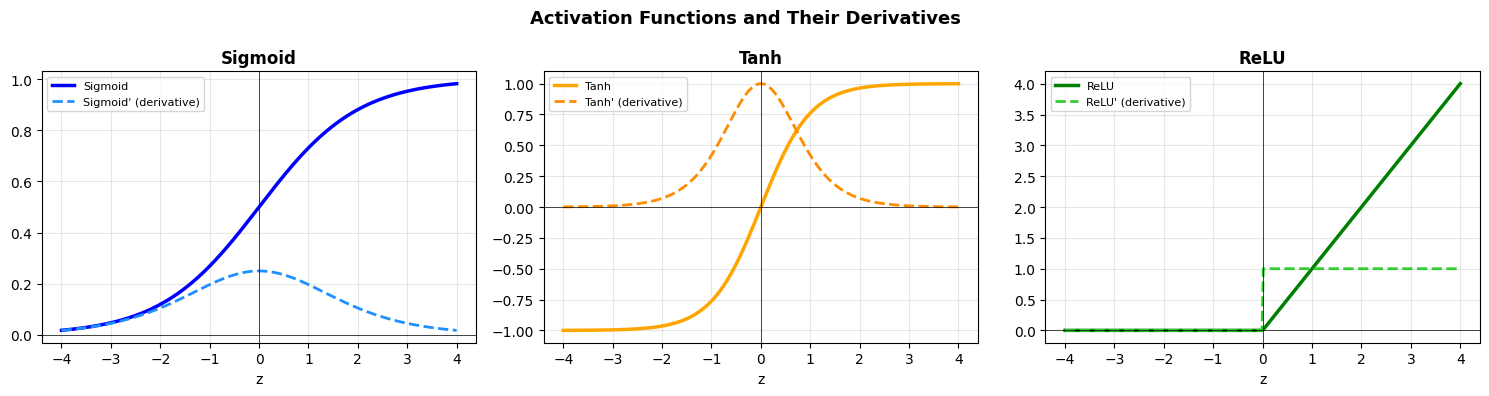

In [38]:
# ── Activation functions + their derivatives ────────────────────────────────

def sigmoid(z):          return 1 / (1 + np.exp(-z))
def sigmoid_grad(z):     s = sigmoid(z); return s * (1 - s)

def tanh_act(z):         return np.tanh(z)
def tanh_grad(z):        return 1 - np.tanh(z) ** 2

def relu(z):             return np.maximum(0, z)
def relu_grad(z):        return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - z.max(axis=0, keepdims=True))
    return e / e.sum(axis=0, keepdims=True)

# Map activation name → (forward_fn, grad_fn)
ACTIVATIONS = {
    'relu':    (relu,     relu_grad),
    'sigmoid': (sigmoid,  sigmoid_grad),
    'tanh':    (tanh_act, tanh_grad),
    'softmax': (softmax,  None),   # combined with loss → special case
    'linear':  (lambda z: z, lambda z: np.ones_like(z)),
}

# ── Plot each activation alongside its derivative ───────────────────────────
z = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

specs = [
    ('Sigmoid',  sigmoid,  sigmoid_grad,  'blue',   'dodgerblue'),
    ('Tanh',     tanh_act, tanh_grad,     'orange', 'darkorange'),
    ('ReLU',     relu,     relu_grad,     'green',  'limegreen'),
]
for ax, (name, fn, gn, c1, c2) in zip(axes, specs):
    ax.plot(z, fn(z), color=c1, lw=2.5, label=f'{name}')
    ax.plot(z, gn(z), color=c2, lw=2, ls='--', label=f"{name}' (derivative)")
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('z')

plt.suptitle('Activation Functions and Their Derivatives', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Step-by-Step Backward Pass

Before building a class, let's trace the backward pass manually through the exact same 2-layer network used in Notebook 3.  
Every gradient shape will be printed so the math maps directly to code.

In [39]:
# ── Tiny 2-layer network  (2 → 3 → 2) ──────────────────────────────────────
# Layer 1: ReLU hidden
# Layer 2: Softmax output

W1 = np.random.randn(3, 2) * 0.1    # (3, 2)
b1 = np.zeros((3, 1))                # (3, 1)
W2 = np.random.randn(2, 3) * 0.1    # (2, 3)
b2 = np.zeros((2, 1))                # (2, 1)

# 4 training samples, 2 features  → shape (2, 4)
X = np.array([[0,0,1,1],
              [0,1,0,1]], dtype=float)
y = np.array([0, 1, 1, 0])   # XOR labels
m = X.shape[1]
K = 2   # number of classes

# One-hot labels  (K, m)
Y = np.eye(K)[:, y]          # [[1,0,0,1], [0,1,1,0]]

print("=" * 55)
print("  FORWARD PASS")
print("=" * 55)

# Layer 1
z1 = W1 @ X + b1              # (3, 4)
a1 = relu(z1)                 # (3, 4)
print(f"  z1  shape : {z1.shape}")
print(f"  a1  shape : {a1.shape}")

# Layer 2
z2 = W2 @ a1 + b2             # (2, 4)
a2 = softmax(z2)              # (2, 4)  ← ŷ
print(f"  z2  shape : {z2.shape}")
print(f"  a2  shape : {a2.shape}  (probabilities)")

# Cross-entropy loss
loss = -np.sum(Y * np.log(np.clip(a2, 1e-12, 1))) / m
print(f"\n  Loss (CE) : {loss:.4f}")

print("\n" + "=" * 55)
print("  BACKWARD PASS")
print("=" * 55)

# ── Layer 2 backward ────────────────────────────────────────────────────────
# Softmax + CE combined gradient: dL/dz2 = (ŷ - y) / m
dz2 = (a2 - Y) / m            # (2, 4)

dW2 = dz2 @ a1.T              # (2, 4)·(4, 3) = (2, 3)  ← same shape as W2
db2 = dz2.sum(axis=1, keepdims=True)  # (2, 1)
da1 = W2.T @ dz2              # (3, 2)·(2, 4) = (3, 4)  ← gradient for a1

print(f"\n  [Layer 2]")
print(f"  dz2 shape : {dz2.shape}  (Softmax+CE combined)")
print(f"  dW2 shape : {dW2.shape}  (matches W2 {W2.shape})")
print(f"  db2 shape : {db2.shape}")
print(f"  da1 shape : {da1.shape}  (propagates into Layer 1)")

# ── Layer 1 backward ────────────────────────────────────────────────────────
# ReLU derivative: pass gradient only where z1 > 0
dz1 = da1 * relu_grad(z1)     # (3, 4) element-wise

dW1 = dz1 @ X.T               # (3, 4)·(4, 2) = (3, 2)  ← same shape as W1
db1 = dz1.sum(axis=1, keepdims=True)  # (3, 1)

print(f"\n  [Layer 1]")
print(f"  dz1 shape : {dz1.shape}  (ReLU gate applied to da1)")
print(f"  dW1 shape : {dW1.shape}  (matches W1 {W1.shape})")
print(f"  db1 shape : {db1.shape}")

print("\n  Gradient shapes match weight shapes — backward pass is correct!")

  FORWARD PASS
  z1  shape : (3, 4)
  a1  shape : (3, 4)
  z2  shape : (2, 4)
  a2  shape : (2, 4)  (probabilities)

  Loss (CE) : 0.6934

  BACKWARD PASS

  [Layer 2]
  dz2 shape : (2, 4)  (Softmax+CE combined)
  dW2 shape : (2, 3)  (matches W2 (2, 3))
  db2 shape : (2, 1)
  da1 shape : (3, 4)  (propagates into Layer 1)

  [Layer 1]
  dz1 shape : (3, 4)  (ReLU gate applied to da1)
  dW1 shape : (3, 2)  (matches W1 (3, 2))
  db1 shape : (3, 1)

  Gradient shapes match weight shapes — backward pass is correct!


## 4. Gradient Checking — Verifying Correctness

Before training, it is essential to verify that our analytical gradients are correct.  
**Numerical gradient checking** perturbs each weight by a tiny $\epsilon$ and checks:

$$
\frac{\partial \mathcal{L}}{\partial \theta_i} \approx \frac{\mathcal{L}(\theta_i + \varepsilon) - \mathcal{L}(\theta_i - \varepsilon)}{2\varepsilon}
$$

The **relative error** between analytical and numerical gradients should be $< 10^{-5}$.

In [40]:
def compute_loss(W1, b1, W2, b2, X, Y):
    """Full forward pass + cross-entropy loss for the 2-layer net above."""
    a1 = relu(W1 @ X + b1)
    a2 = softmax(W2 @ a1 + b2)
    return -np.sum(Y * np.log(np.clip(a2, 1e-12, 1))) / X.shape[1]


def numerical_gradient(W, loss_fn, epsilon=1e-5):
    """Compute numerical gradient for every element of weight matrix W."""
    grad = np.zeros_like(W)
    it = np.nditer(W, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        orig = W[idx]
        W[idx] = orig + epsilon
        L_plus  = loss_fn()
        W[idx] = orig - epsilon
        L_minus = loss_fn()
        grad[idx] = (L_plus - L_minus) / (2 * epsilon)
        W[idx] = orig
        it.iternext()
    return grad


# ── Check dW2 ───────────────────────────────────────────────────────────────
num_dW2 = numerical_gradient(
    W2,
    lambda: compute_loss(W1, b1, W2, b2, X, Y)
)

# ── Check dW1 ───────────────────────────────────────────────────────────────
num_dW1 = numerical_gradient(
    W1,
    lambda: compute_loss(W1, b1, W2, b2, X, Y)
)


def relative_error(a, b):
    return np.max(np.abs(a - b) / (np.abs(a) + np.abs(b) + 1e-8))


err_W2 = relative_error(dW2, num_dW2)
err_W1 = relative_error(dW1, num_dW1)

print("Gradient Check Results")
print("-" * 45)
print(f"  dW2 — relative error: {err_W2:.2e}  {'PASS ✓' if err_W2 < 1e-5 else 'FAIL ✗'}")
print(f"  dW1 — relative error: {err_W1:.2e}  {'PASS ✓' if err_W1 < 1e-5 else 'FAIL ✗'}")
print()
print("  Threshold: < 1e-5")
print("  Relative error < 1e-5 → analytical gradients are correct.")

Gradient Check Results
---------------------------------------------
  dW2 — relative error: 1.87e-09  PASS ✓
  dW1 — relative error: 1.50e-08  PASS ✓

  Threshold: < 1e-5
  Relative error < 1e-5 → analytical gradients are correct.


## 5. Gradient Descent — The Update Rule

Once we have gradients, the simplest update rule is **vanilla gradient descent**:

$$
W^{[l]} \leftarrow W^{[l]} - \alpha \, \frac{\partial \mathcal{L}}{\partial W^{[l]}}
$$

where $\alpha$ is the **learning rate** — the single most important hyperparameter in neural network training.

### Intuition: a loss surface

Think of $\mathcal{L}$ as a hilly landscape. The gradient tells you which direction is uphill. We step in the **opposite** direction to descend toward a minimum.

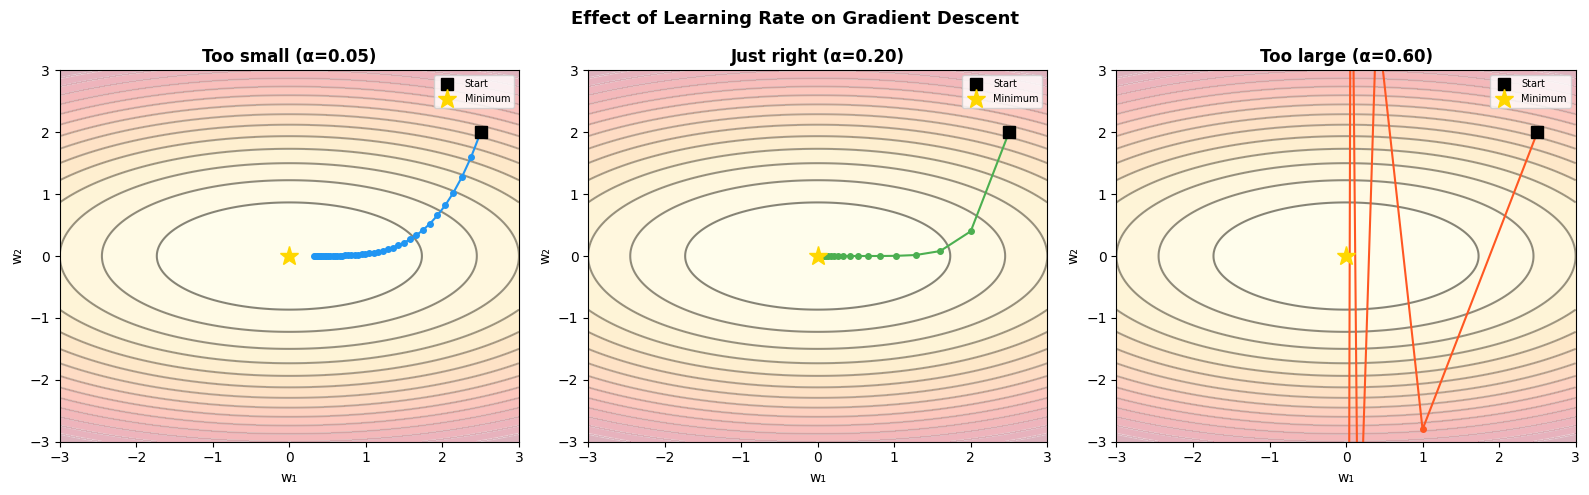

In [41]:
# Visualise gradient descent on a 2-D convex loss surface
def bowl(w1, w2): return 0.5 * w1**2 + 2 * w2**2
def bowl_grad(w1, w2): return np.array([w1, 4 * w2])

# Stability condition: lr * max_curvature < 2  →  lr * 4 < 2  →  lr < 0.5
# lr=0.05: converges slowly (stable, lr << 0.5)
# lr=0.20: converges well   (stable, lr < 0.5)
# lr=0.60: diverges         (unstable, lr > 0.5)

w = np.linspace(-3, 3, 200)
W1g, W2g = np.meshgrid(w, w)
Z = bowl(W1g, W2g)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

learning_rates = [0.05, 0.20, 0.60]
titles = ['Too small (α=0.05)', 'Just right (α=0.20)', 'Too large (α=0.60)']
colors = ['#2196F3', '#4CAF50', '#FF5722']

for ax, lr, title, color in zip(axes, learning_rates, titles, colors):
    ax.contour(W1g, W2g, Z, levels=20, cmap='gray', alpha=0.5)
    ax.contourf(W1g, W2g, Z, levels=20, cmap='YlOrRd', alpha=0.3)

    path = [np.array([2.5, 2.0])]
    for _ in range(40):
        g = bowl_grad(*path[-1])
        path.append(path[-1] - lr * g)
        if np.linalg.norm(path[-1]) > 8: break   # diverging

    pts = np.array(path)
    ax.plot(pts[:, 0], pts[:, 1], 'o-', color=color, ms=4, lw=1.5)
    ax.plot(pts[0, 0], pts[0, 1], 's', color='black', ms=8, label='Start')
    ax.plot(0, 0, '*', color='gold', ms=14, label='Minimum')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
    ax.legend(fontsize=7)

plt.suptitle('Effect of Learning Rate on Gradient Descent', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Optimizers

Vanilla SGD suffers from slow convergence and sensitivity to learning rate.  
Modern optimizers address these issues with adaptive step sizes and gradient smoothing.

### 6.1 SGD with Momentum
Accumulates a "velocity" vector that damps oscillations and accelerates in consistent directions:
$$v \leftarrow \beta v + (1 - \beta)\, dW \qquad W \leftarrow W - \alpha v$$

### 6.2 RMSProp
Divides the learning rate by a running average of recent gradient magnitudes — effectively giving each parameter its own adaptive rate:
$$s \leftarrow \beta s + (1 - \beta)\, dW^2 \qquad W \leftarrow W - \frac{\alpha}{\sqrt{s + \varepsilon}} dW$$

### 6.3 Adam (Adaptive Moment Estimation)
Combines Momentum (first moment) and RMSProp (second moment) with bias correction:
$$
m \leftarrow \beta_1 m + (1 - \beta_1) dW \qquad
v \leftarrow \beta_2 v + (1 - \beta_2) dW^2
$$
$$
\hat{m} = \frac{m}{1 - \beta_1^t} \qquad \hat{v} = \frac{v}{1 - \beta_2^t}
\qquad W \leftarrow W - \frac{\alpha\,\hat{m}}{\sqrt{\hat{v}} + \varepsilon}
$$

In [42]:
class SGD:
    """Vanilla stochastic gradient descent."""

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads, **_):
        for key in params:
            params[key] -= self.lr * grads[key]


class Momentum:
    """SGD + Momentum."""

    def __init__(self, lr=0.01, beta=0.9):
        self.lr, self.beta = lr, beta
        self.velocity = {}

    def update(self, params, grads, **_):
        for key in params:
            if key not in self.velocity:
                self.velocity[key] = np.zeros_like(params[key])
            self.velocity[key] = (self.beta * self.velocity[key]
                                  + (1 - self.beta) * grads[key])
            params[key] -= self.lr * self.velocity[key]


class RMSProp:
    """RMSProp."""

    def __init__(self, lr=0.001, beta=0.99, eps=1e-8):
        self.lr, self.beta, self.eps = lr, beta, eps
        self.sq_grad = {}

    def update(self, params, grads, **_):
        for key in params:
            if key not in self.sq_grad:
                self.sq_grad[key] = np.zeros_like(params[key])
            self.sq_grad[key] = (self.beta * self.sq_grad[key]
                                 + (1 - self.beta) * grads[key] ** 2)
            params[key] -= (self.lr / (np.sqrt(self.sq_grad[key]) + self.eps)
                            * grads[key])


class Adam:
    """Adam optimizer with bias correction."""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
        self.m, self.v = {}, {}
        self.t = 0

    def update(self, params, grads, **_):
        self.t += 1
        for key in params:
            if key not in self.m:
                self.m[key] = np.zeros_like(params[key])
                self.v[key] = np.zeros_like(params[key])

            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2

            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


print("Optimizers defined: SGD, Momentum, RMSProp, Adam")

Optimizers defined: SGD, Momentum, RMSProp, Adam


## 7. Full Neural Network — Forward + Backward + Training Loop

We now assemble everything into a single `NeuralNetwork` class that supports arbitrary depth, multiple activation functions, pluggable optimizers, and mini-batch training.

In [43]:
class NeuralNetwork:
    """
    Fully-connected neural network with forward + backward pass.

    Parameters
    ----------
    layer_dims  : list[int]   – e.g. [2, 4, 4, 2] (includes input & output)
    activations : list[str]   – one per non-input layer, e.g. ['relu', 'relu', 'softmax']
    optimizer   : optimizer   – SGD / Momentum / RMSProp / Adam instance
    """

    def __init__(self, layer_dims, activations, optimizer=None):
        assert len(activations) == len(layer_dims) - 1
        self.layer_dims  = layer_dims
        self.activations = activations
        self.optimizer   = optimizer or SGD(lr=0.01)
        self.params      = {}
        self.cache       = {}
        self.history     = {'loss': [], 'acc': []}
        self._init_params()

    # ── Weight initialisation (He for ReLU, Xavier otherwise) ───────────────
    def _init_params(self):
        for l in range(1, len(self.layer_dims)):
            fan_in = self.layer_dims[l - 1]
            scale  = (np.sqrt(2 / fan_in)
                      if self.activations[l - 1] == 'relu'
                      else np.sqrt(1 / fan_in))
            self.params[f'W{l}'] = np.random.randn(self.layer_dims[l], fan_in) * scale
            self.params[f'b{l}'] = np.zeros((self.layer_dims[l], 1))

    # ── Forward pass ────────────────────────────────────────────────────────
    def forward(self, X):
        self.cache['a0'] = X
        a = X
        L = len(self.layer_dims) - 1
        for l in range(1, L + 1):
            z = self.params[f'W{l}'] @ a + self.params[f'b{l}']
            fn, _ = ACTIVATIONS[self.activations[l - 1]]
            a = fn(z)
            self.cache[f'z{l}'] = z
            self.cache[f'a{l}'] = a
        return a

    # ── Loss (categorical cross-entropy) ────────────────────────────────────
    def compute_loss(self, y_hat, Y_onehot):
        m = Y_onehot.shape[1]
        return -np.sum(Y_onehot * np.log(np.clip(y_hat, 1e-12, 1))) / m

    # ── Backward pass ───────────────────────────────────────────────────────
    def backward(self, Y_onehot):
        grads = {}
        L = len(self.layer_dims) - 1
        m = Y_onehot.shape[1]

        # Output layer: combined Softmax + CE gradient
        a_L = self.cache[f'a{L}']
        dz  = (a_L - Y_onehot) / m     # (n_L, m)

        for l in range(L, 0, -1):
            a_prev = self.cache[f'a{l-1}']
            W_l    = self.params[f'W{l}']

            grads[f'W{l}'] = dz @ a_prev.T
            grads[f'b{l}'] = dz.sum(axis=1, keepdims=True)

            if l > 1:   # propagate error to previous layer
                da_prev  = W_l.T @ dz
                _, gn    = ACTIVATIONS[self.activations[l - 2]]
                dz       = da_prev * gn(self.cache[f'z{l-1}'])

        return grads

    # ── Training step (one epoch / mini-batch) ───────────────────────────────
    def _step(self, X, Y_onehot):
        y_hat = self.forward(X)
        loss  = self.compute_loss(y_hat, Y_onehot)
        grads = self.backward(Y_onehot)
        self.optimizer.update(self.params, grads)
        return loss, y_hat

    # ── Full training loop ──────────────────────────────────────────────────
    def fit(self, X, y, epochs=1000, batch_size=None, verbose=True, log_every=100):
        """
        Train the network.

        Parameters
        ----------
        X          : np.ndarray, shape (n_features, m)
        y          : np.ndarray, shape (m,)  – integer class labels
        epochs     : int
        batch_size : int or None (None = full-batch gradient descent)
        """
        K = self.layer_dims[-1]
        Y = np.eye(K)[:, y]              # one-hot (K, m)
        m = X.shape[1]

        for epoch in range(1, epochs + 1):
            if batch_size is None:
                loss, y_hat = self._step(X, Y)
            else:
                # Mini-batch loop
                idx = np.random.permutation(m)
                loss_sum = 0
                for start in range(0, m, batch_size):
                    b = idx[start:start + batch_size]
                    loss_b, _ = self._step(X[:, b], Y[:, b])
                    loss_sum += loss_b
                loss  = loss_sum / (m // batch_size + 1)
                y_hat = self.forward(X)

            acc = (np.argmax(y_hat, axis=0) == y).mean()
            self.history['loss'].append(loss)
            self.history['acc'].append(acc)

            if verbose and epoch % log_every == 0:
                print(f"  Epoch {epoch:5d}/{epochs}  loss={loss:.4f}  acc={acc*100:.1f}%")

    def predict(self, X):
        return np.argmax(self.forward(X), axis=0)

    def score(self, X, y):
        return (self.predict(X) == y).mean()


print("NeuralNetwork class ready.")

NeuralNetwork class ready.


## 8. Sanity Check — Solving XOR

XOR is the classic test case for MLP training. A single perceptron cannot solve it; a 2-layer MLP with backpropagation can.

In [44]:
np.random.seed(42)

# XOR dataset
X_xor = np.array([[0,0,1,1],
                   [0,1,0,1]], dtype=float)   # (2, 4)
y_xor = np.array([0, 1, 1, 0])               # labels

xor_net = NeuralNetwork(
    layer_dims  = [2, 4, 2],
    activations = ['relu', 'softmax'],
    optimizer   = Adam(lr=0.05)
)

xor_net.fit(X_xor, y_xor, epochs=2000, verbose=True, log_every=500)

print("\nFinal predictions:")
probs = xor_net.forward(X_xor)
for i in range(4):
    pred = np.argmax(probs[:, i])
    conf = probs[pred, i] * 100
    symbol = '✓' if pred == y_xor[i] else '✗'
    print(f"  Input [{int(X_xor[0,i])},{int(X_xor[1,i])}]  true={y_xor[i]}  pred={pred}  conf={conf:.1f}%  {symbol}")

  Epoch   500/2000  loss=0.0009  acc=100.0%
  Epoch  1000/2000  loss=0.0003  acc=100.0%
  Epoch  1500/2000  loss=0.0001  acc=100.0%
  Epoch  2000/2000  loss=0.0001  acc=100.0%

Final predictions:
  Input [0,0]  true=0  pred=0  conf=100.0%  ✓
  Input [0,1]  true=1  pred=1  conf=100.0%  ✓
  Input [1,0]  true=1  pred=1  conf=100.0%  ✓
  Input [1,1]  true=0  pred=0  conf=100.0%  ✓


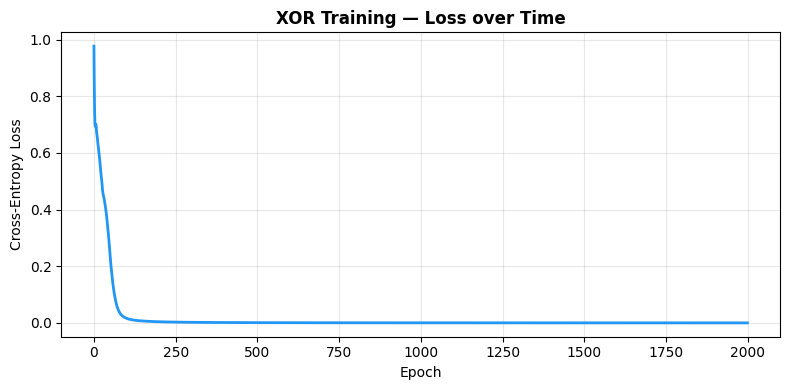

In [45]:
# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(xor_net.history['loss'], color='#2196F3', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('XOR Training — Loss over Time', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Training on make_moons — Decision Boundary Visualisation

Now let's train on a more realistic non-linearly separable dataset and watch the network learn a curved boundary.

In [46]:
np.random.seed(42)

# ── Dataset ─────────────────────────────────────────────────────────────────
X_raw, y_moons = make_moons(n_samples=400, noise=0.2, random_state=42)
scaler = StandardScaler()
X_moons = scaler.fit_transform(X_raw).T   # (2, 400)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_moons.T, y_moons, test_size=0.2, random_state=42
)
X_tr, X_te = X_tr.T, X_te.T              # back to (features, m)

print(f"Train: {X_tr.shape[1]} samples   Test: {X_te.shape[1]} samples")

Train: 320 samples   Test: 80 samples


In [47]:
np.random.seed(42)

moon_net = NeuralNetwork(
    layer_dims  = [2, 16, 8, 2],
    activations = ['relu', 'relu', 'softmax'],
    optimizer   = Adam(lr=0.01)
)

moon_net.fit(X_tr, y_tr, epochs=1500, batch_size=64, verbose=True, log_every=300)

train_acc = moon_net.score(X_tr, y_tr) * 100
test_acc  = moon_net.score(X_te, y_te) * 100
print(f"\nTrain accuracy : {train_acc:.1f}%")
print(f"Test  accuracy : {test_acc:.1f}%")

  Epoch   300/1500  loss=0.0312  acc=98.8%
  Epoch   600/1500  loss=0.0264  acc=98.8%
  Epoch   900/1500  loss=0.0203  acc=99.4%
  Epoch  1200/1500  loss=0.0137  acc=99.7%
  Epoch  1500/1500  loss=0.0113  acc=99.1%

Train accuracy : 99.1%
Test  accuracy : 95.0%


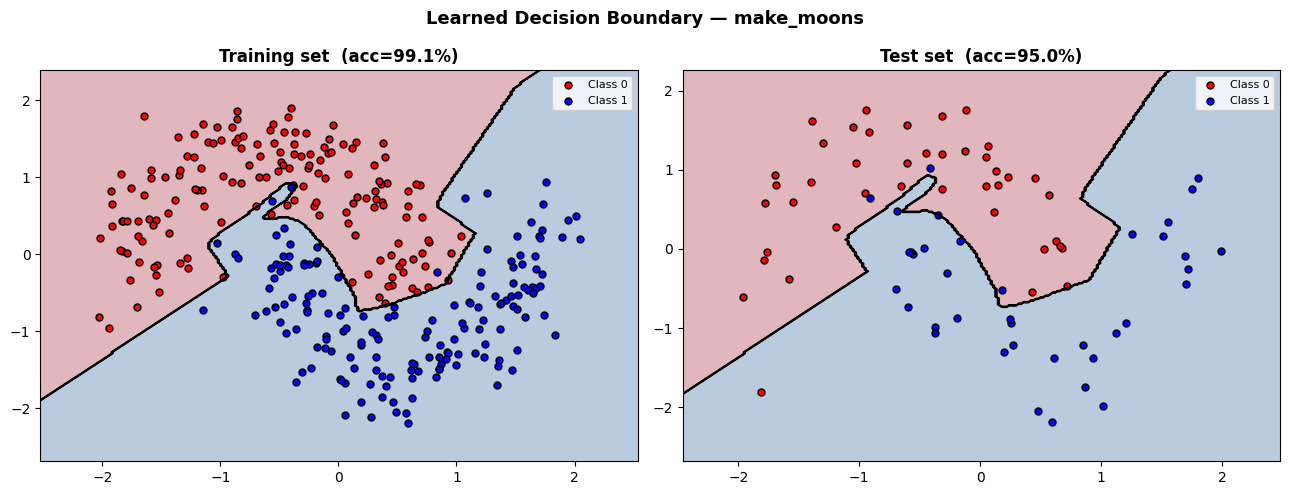

In [48]:
def plot_decision_boundary(model, X, y, ax, title=""):
    """Colour the 2-D input space by the model's predicted class."""
    h = 0.02
    x0_min, x0_max = X[0].min() - 0.5, X[0].max() + 0.5
    x1_min, x1_max = X[1].min() - 0.5, X[1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()].T   # (2, N)
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8)
    ax.scatter(X[0, y == 0], X[1, y == 0], c='red',  edgecolors='k', s=25, label='Class 0')
    ax.scatter(X[0, y == 1], X[1, y == 1], c='blue', edgecolors='k', s=25, label='Class 1')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_decision_boundary(moon_net, X_tr, y_tr, axes[0],
                       f'Training set  (acc={train_acc:.1f}%)')
plot_decision_boundary(moon_net, X_te, y_te, axes[1],
                       f'Test set  (acc={test_acc:.1f}%)')
plt.suptitle('Learned Decision Boundary — make_moons', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Learning Rate Effect on Training

The learning rate controls how big each weight update step is. Let's train five identical networks with different learning rates and compare their loss curves.

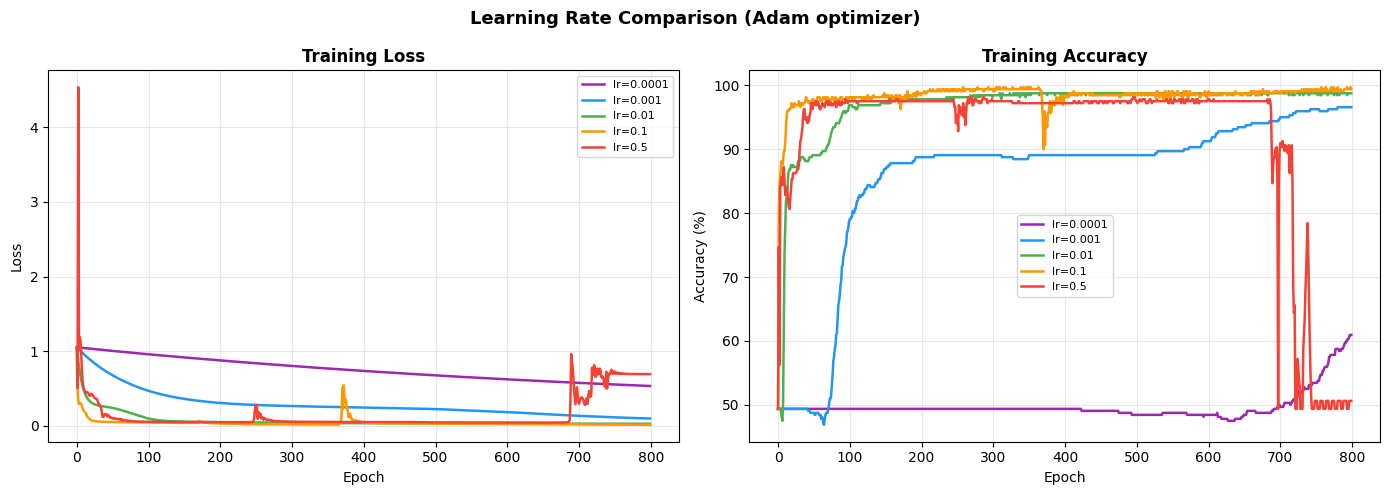

In [49]:
EPOCHS = 800
learning_rates = [1e-4, 1e-3, 1e-2, 0.1, 0.5]
lr_colors = ['#9C27B0', '#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

for lr, color in zip(learning_rates, lr_colors):
    np.random.seed(42)
    net = NeuralNetwork(
        layer_dims  = [2, 16, 8, 2],
        activations = ['relu', 'relu', 'softmax'],
        optimizer   = Adam(lr=lr)
    )
    net.fit(X_tr, y_tr, epochs=EPOCHS, verbose=False)

    label = f'lr={lr}'
    ax_loss.plot(net.history['loss'], color=color, lw=1.8, label=label)
    ax_acc.plot( [a * 100 for a in net.history['acc']], color=color, lw=1.8, label=label)

for ax, ylabel, title in [
    (ax_loss, 'Loss',         'Training Loss'),
    (ax_acc,  'Accuracy (%)', 'Training Accuracy'),
]:
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Rate Comparison (Adam optimizer)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Optimizer Comparison

All four optimizers trained with the same learning rate and architecture.  
We compare their **loss curves** and **final test accuracy** to understand their practical differences.

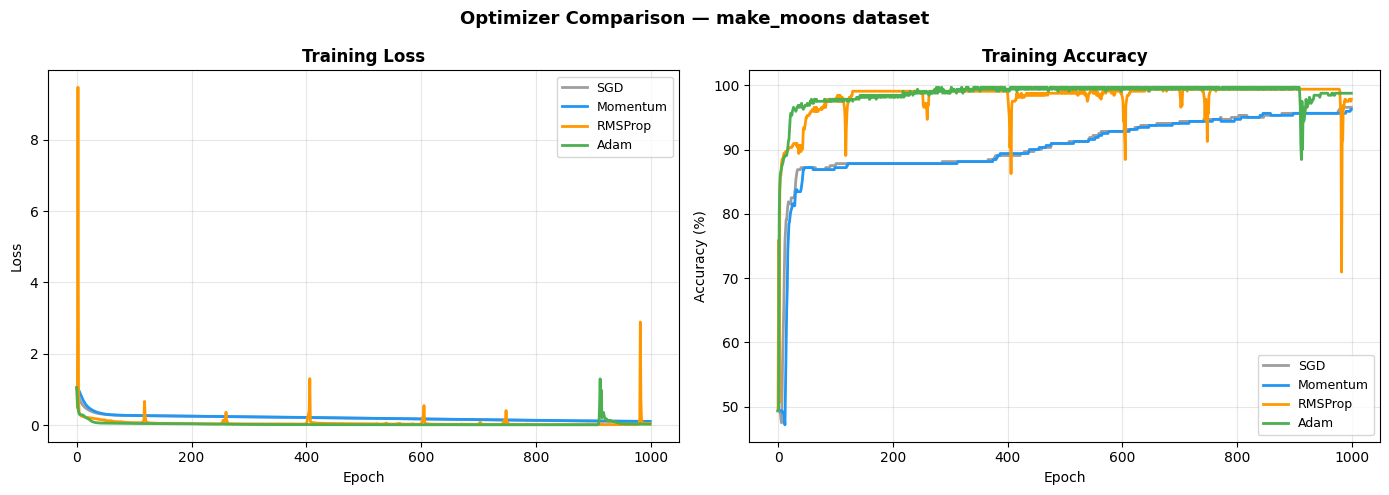


Final Test Accuracy Summary
-----------------------------------
  SGD           test acc = 92.5%
  Momentum      test acc = 92.5%
  RMSProp       test acc = 91.2%
  Adam          test acc = 93.8%


In [55]:
EPOCHS = 1000

optimizer_configs = [
    ('SGD',       SGD(lr=0.05),          '#9E9E9E'),
    ('Momentum',  Momentum(lr=0.05),     '#2196F3'),
    ('RMSProp',   RMSProp(lr=0.05),     '#FF9800'),
    ('Adam',      Adam(lr=0.05),         '#4CAF50'),
]

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, opt, color in optimizer_configs:
    np.random.seed(42)
    net = NeuralNetwork(
        layer_dims  = [2, 16, 8, 2],
        activations = ['relu', 'relu', 'softmax'],
        optimizer   = opt
    )
    net.fit(X_tr, y_tr, epochs=EPOCHS, verbose=False)
    test_acc = net.score(X_te, y_te) * 100
    results[name] = {'net': net, 'test_acc': test_acc, 'color': color}

    axes[0].plot(net.history['loss'], color=color, lw=2, label=f'{name}')
    axes[1].plot([a*100 for a in net.history['acc']], color=color, lw=2, label=f'{name}')

for ax, ylabel, title in [
    (axes[0], 'Loss',         'Training Loss'),
    (axes[1], 'Accuracy (%)', 'Training Accuracy'),
]:
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison — make_moons dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFinal Test Accuracy Summary")
print("-" * 35)
for name, res in results.items():
    print(f"  {name:<12}  test acc = {res['test_acc']:.1f}%")

## 12. Decision Boundaries — All Optimizers Side by Side

Different optimizers may converge to slightly different minima. Let's visualise the decision boundaries they found.

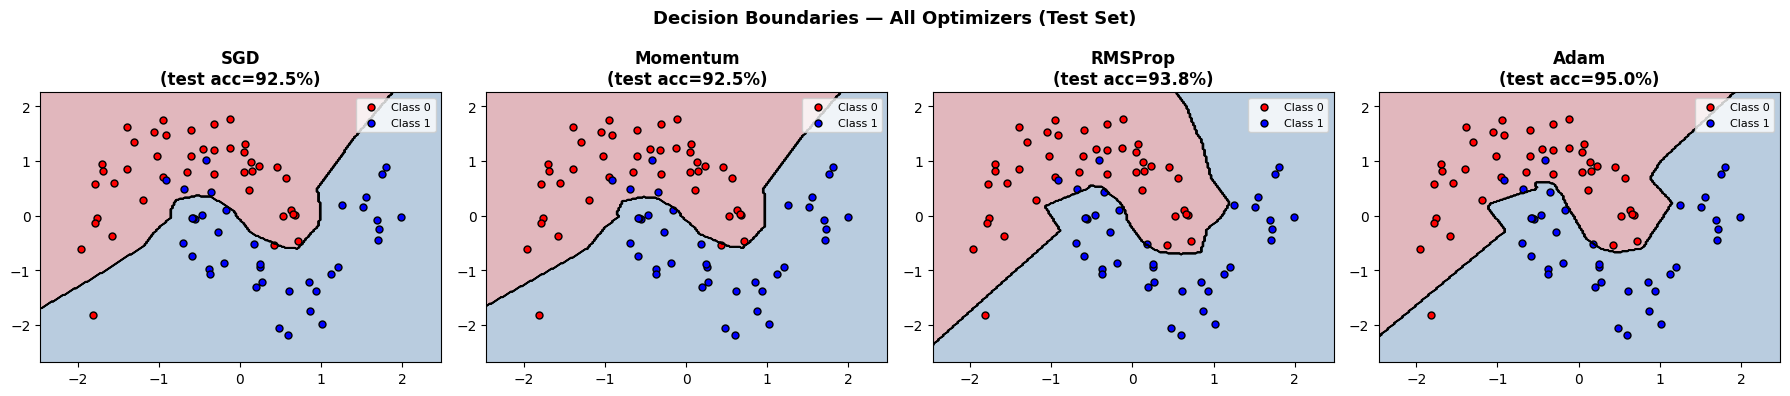

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, res) in zip(axes, results.items()):
    plot_decision_boundary(
        res['net'], X_te, y_te, ax,
        title=f"{name}\n(test acc={res['test_acc']:.1f}%)"
    )

plt.suptitle('Decision Boundaries — All Optimizers (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. End-to-End: Iris Dataset (3-Class)

Finally, apply the trained network to the Iris dataset — a 3-class, 4-feature classification problem.  
This confirms that everything generalises beyond binary classification.

In [52]:
np.random.seed(42)

iris = load_iris()
X_raw_iris, y_iris = iris.data, iris.target

sc = StandardScaler()
X_iris = sc.fit_transform(X_raw_iris).T   # (4, 150)

X_itr, X_ite, y_itr, y_ite = train_test_split(
    X_iris.T, y_iris, test_size=0.2, stratify=y_iris, random_state=42
)
X_itr, X_ite = X_itr.T, X_ite.T

iris_net = NeuralNetwork(
    layer_dims  = [4, 16, 8, 3],
    activations = ['relu', 'relu', 'softmax'],
    optimizer   = Adam(lr=0.01)
)

iris_net.fit(X_itr, y_itr, epochs=2000, verbose=True, log_every=400)

train_acc = iris_net.score(X_itr, y_itr) * 100
test_acc  = iris_net.score(X_ite, y_ite) * 100
print(f"\nTrain accuracy : {train_acc:.1f}%")
print(f"Test  accuracy : {test_acc:.1f}%")

  Epoch   400/2000  loss=0.0018  acc=100.0%
  Epoch   800/2000  loss=0.0003  acc=100.0%
  Epoch  1200/2000  loss=0.0001  acc=100.0%
  Epoch  1600/2000  loss=0.0001  acc=100.0%
  Epoch  2000/2000  loss=0.0000  acc=100.0%

Train accuracy : 100.0%
Test  accuracy : 86.7%


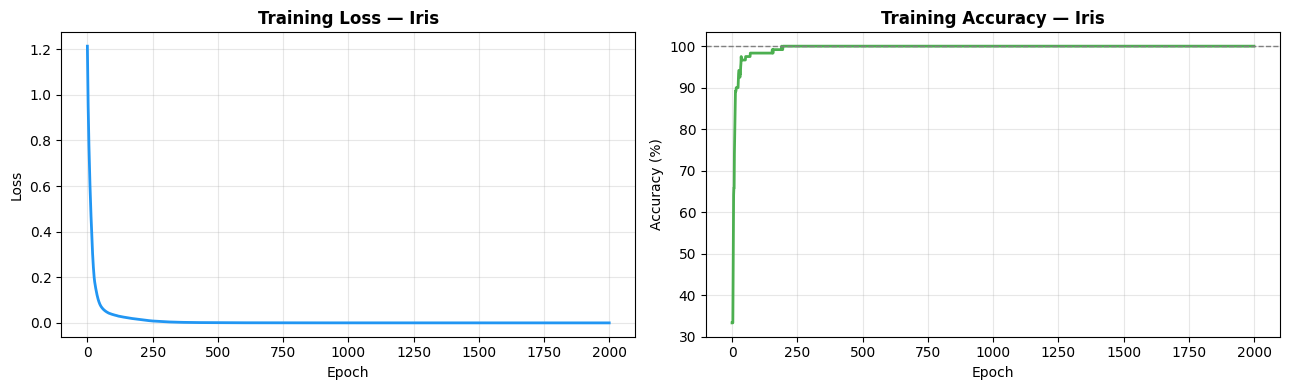

In [53]:
# Loss + Accuracy curves for Iris
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(iris_net.history['loss'], color='#2196F3', lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss — Iris', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot([a * 100 for a in iris_net.history['acc']], color='#4CAF50', lw=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy — Iris', fontweight='bold')
ax2.axhline(100, color='gray', ls='--', lw=1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

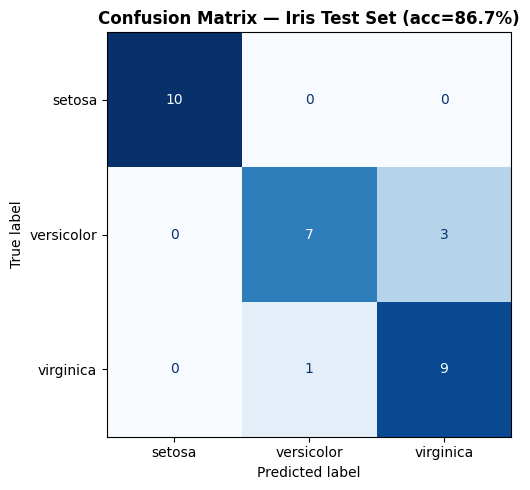

In [54]:
# Confusion matrix on test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_iris = iris_net.predict(X_ite)

cm = confusion_matrix(y_ite, y_pred_iris)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Iris Test Set (acc={test_acc:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Concept | Key takeaway |
|---|---|
| **Chain rule** | Gradient of loss w.r.t. any weight = product of local gradients along the path |
| **Error signal $\delta^{[l]}$** | The quantity propagated backwards; encodes how much each pre-activation contributed to the loss |
| **Softmax + CE gradient** | $\hat{y} - y$ — an elegant simplification from the chain rule |
| **ReLU gradient** | 1 where $z > 0$, else 0 — acts as a gate that blocks or passes the error signal |
| **Gradient checking** | Finite-difference numerical check with relative error $< 10^{-5}$ confirms correctness |
| **SGD** | Simple, effective; sensitive to learning rate and noisy on small batches |
| **Momentum** | Smooths updates; escapes local flat regions faster |
| **RMSProp** | Per-parameter adaptive rate; handles sparse/non-stationary gradients |
| **Adam** | Best of Momentum + RMSProp with bias correction; default choice for most tasks |
| **Learning rate** | Most critical hyperparameter — too small: slow; too large: diverges |

